<a href="https://colab.research.google.com/github/Juanesingindustrial/ciencai-de-datos-2026/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "diabetes.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/pima-indians-diabetes-database",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_11924/2709689075.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
First 5 records:    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [5]:
import pandas as pd
import numpy as np

# Copia del dataset
df_clean = df.copy()

# Reemplazar ceros por NaN en variables donde no tiene sentido
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean[cols] = df_clean[cols].replace(0, np.nan)

# Rellenar con la mediana
df_clean.fillna(df_clean.median(), inplace=True)

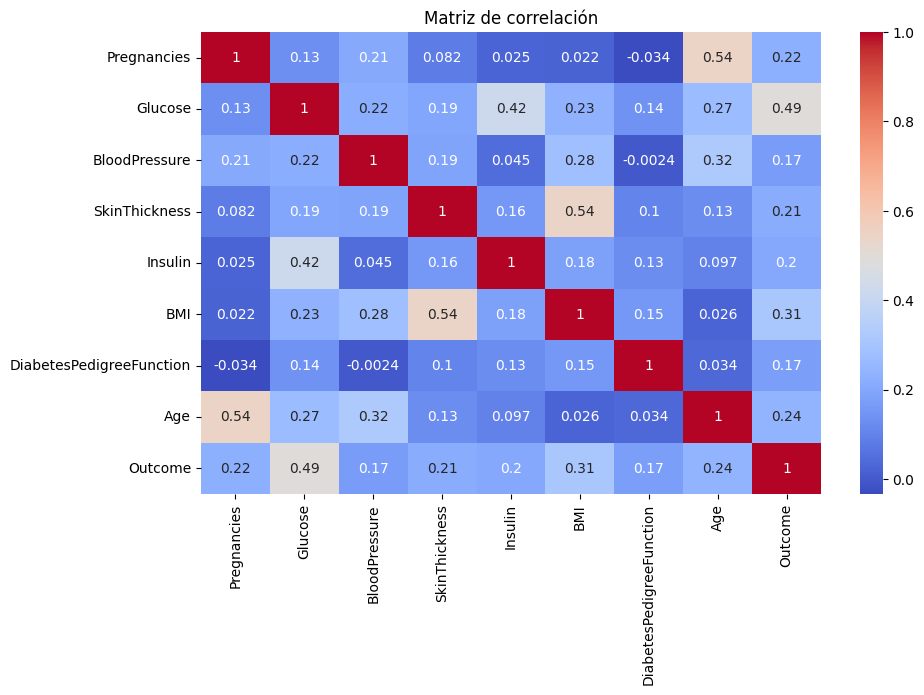

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_clean.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

# Ver correlación con Outcome
print(corr["Outcome"].sort_values(ascending=False))

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

Glucose                     0.257168
BMI                         0.155095
Age                         0.144491
DiabetesPedigreeFunction    0.116575
Insulin                     0.094815
BloodPressure               0.085349
SkinThickness               0.073287
Pregnancies                 0.073221
dtype: float64


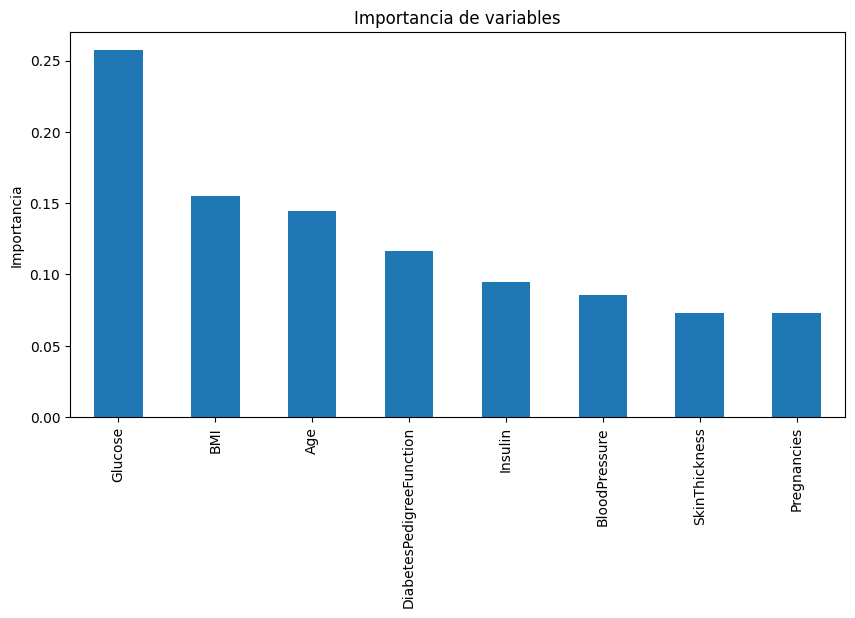

In [8]:
importances.plot(kind="bar", figsize=(10,5))
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.show()

In [9]:
plt.savefig("grafica.png")

<Figure size 640x480 with 0 Axes>